In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import datetime

from sklearn.model_selection import train_test_split, TimeSeriesSplit, cross_val_score, learning_curve
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
import shap

# Chargement
from src.config import *
from src.utils import *

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, log_loss, confusion_matrix
)


e:\Documents_\Dev\NBA_Predictor\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
#store start time of notebook
start_time = datetime.datetime.now()
print("Start time: ", start_time)

Start time:  2025-06-12 21:24:34.426514


In [3]:
#load latest final dataset cleaned

final_dataset_file = get_latest_file(DATA_FINAL_CLEANED_DATASET_DIR)

df = pd.read_csv(final_dataset_file)
print("Loaded dataset: ", final_dataset_file)


Loaded dataset:  data\final_cleaned_dataset\nba_features_cleaned_final_2025-06-12_20-02-49.csv


# -------- 1. Analyse rapide --------


'Colonnes:'

['GAME_ID',
 'GAME_DATE',
 'TEAM_ID',
 'OPP_TEAM_ID',
 'IS_HOME',
 'IS_WIN',
 'POINT_DIFF',
 'has_absent',
 'has_top_absent',
 'num_absent',
 'top_player_absent',
 'ODDS',
 'OPP_ODDS',
 'SEASON',
 'ROLL_fieldGoalsMade_traditional_3',
 'ROLL_fieldGoalsMade_traditional_5',
 'ROLL_fieldGoalsMade_traditional_10',
 'ROLL_fieldGoalsMade_traditional_25',
 'ROLL_fieldGoalsMade_traditional_50',
 'ROLL_fieldGoalsMade_traditional_100',
 'ROLL_fieldGoalsMade_traditional_200',
 'ROLL_fieldGoalsAttempted_traditional_3',
 'ROLL_fieldGoalsAttempted_traditional_5',
 'ROLL_fieldGoalsAttempted_traditional_10',
 'ROLL_fieldGoalsAttempted_traditional_25',
 'ROLL_fieldGoalsAttempted_traditional_50',
 'ROLL_fieldGoalsAttempted_traditional_100',
 'ROLL_fieldGoalsAttempted_traditional_200',
 'ROLL_threePointersMade_traditional_3',
 'ROLL_threePointersMade_traditional_5',
 'ROLL_threePointersMade_traditional_10',
 'ROLL_threePointersMade_traditional_25',
 'ROLL_threePointersMade_traditional_50',
 'ROLL_threePoi

'Échantillon:\n'

,GAME_ID,GAME_DATE,TEAM_ID,OPP_TEAM_ID,IS_HOME,IS_WIN,POINT_DIFF,has_absent,has_top_absent,num_absent,...,H2H_LAST_100_COUNT,H2H_LAST_200_DIFF,H2H_LAST_200_WINRATE,H2H_LAST_200_COUNT,H2H_SEASON_WINS,H2H_SEASON_MATCHES,H2H_SEASON_WINRATE,H2H_WIN_STREAK,ELO_DIFF,ELO_DIFF_SEASON
38077,42400305,2025-05-29,1610612752,1610612754,1.0,1.0,17.0,1,0,4,...,69,-13,0.405797,69,3,7,0.428571,0,-88.265741,-90.848631
38078,42400305,2025-05-29,1610612754,1610612752,0.0,0.0,-17.0,1,0,2,...,69,13,0.594203,69,4,7,0.571429,1,88.265741,90.848631
38079,42400306,2025-05-31,1610612752,1610612754,0.0,0.0,-17.0,1,0,2,...,70,-12,0.414286,70,4,8,0.500000,1,-58.786924,-61.203808
38080,42400306,2025-05-31,1610612754,1610612752,1.0,1.0,17.0,1,0,2,...,70,12,0.585714,70,4,8,0.500000,0,58.786924,61.203808


'Distribution des cibles:\n'

IS_WIN
0.0    0.500328
1.0    0.499672
Name: proportion, dtype: float64

'Valeurs manquantes:\n'

ROLL_WIN_RATIO_200                       30
ROLL_WIN_RATIO_100                       30
ROLL_WIN_RATIO_50                        30
ROLL_WIN_RATIO_25                        30
ROLL_WIN_RATIO_10                        30
ROLL_WIN_RATIO_5                         30
ROLL_WIN_RATIO_3                         30
ROLL_threePointersMade_traditional_25    30
ROLL_threePointersMade_traditional_10    30
ROLL_threePointersMade_traditional_5     30
dtype: int64

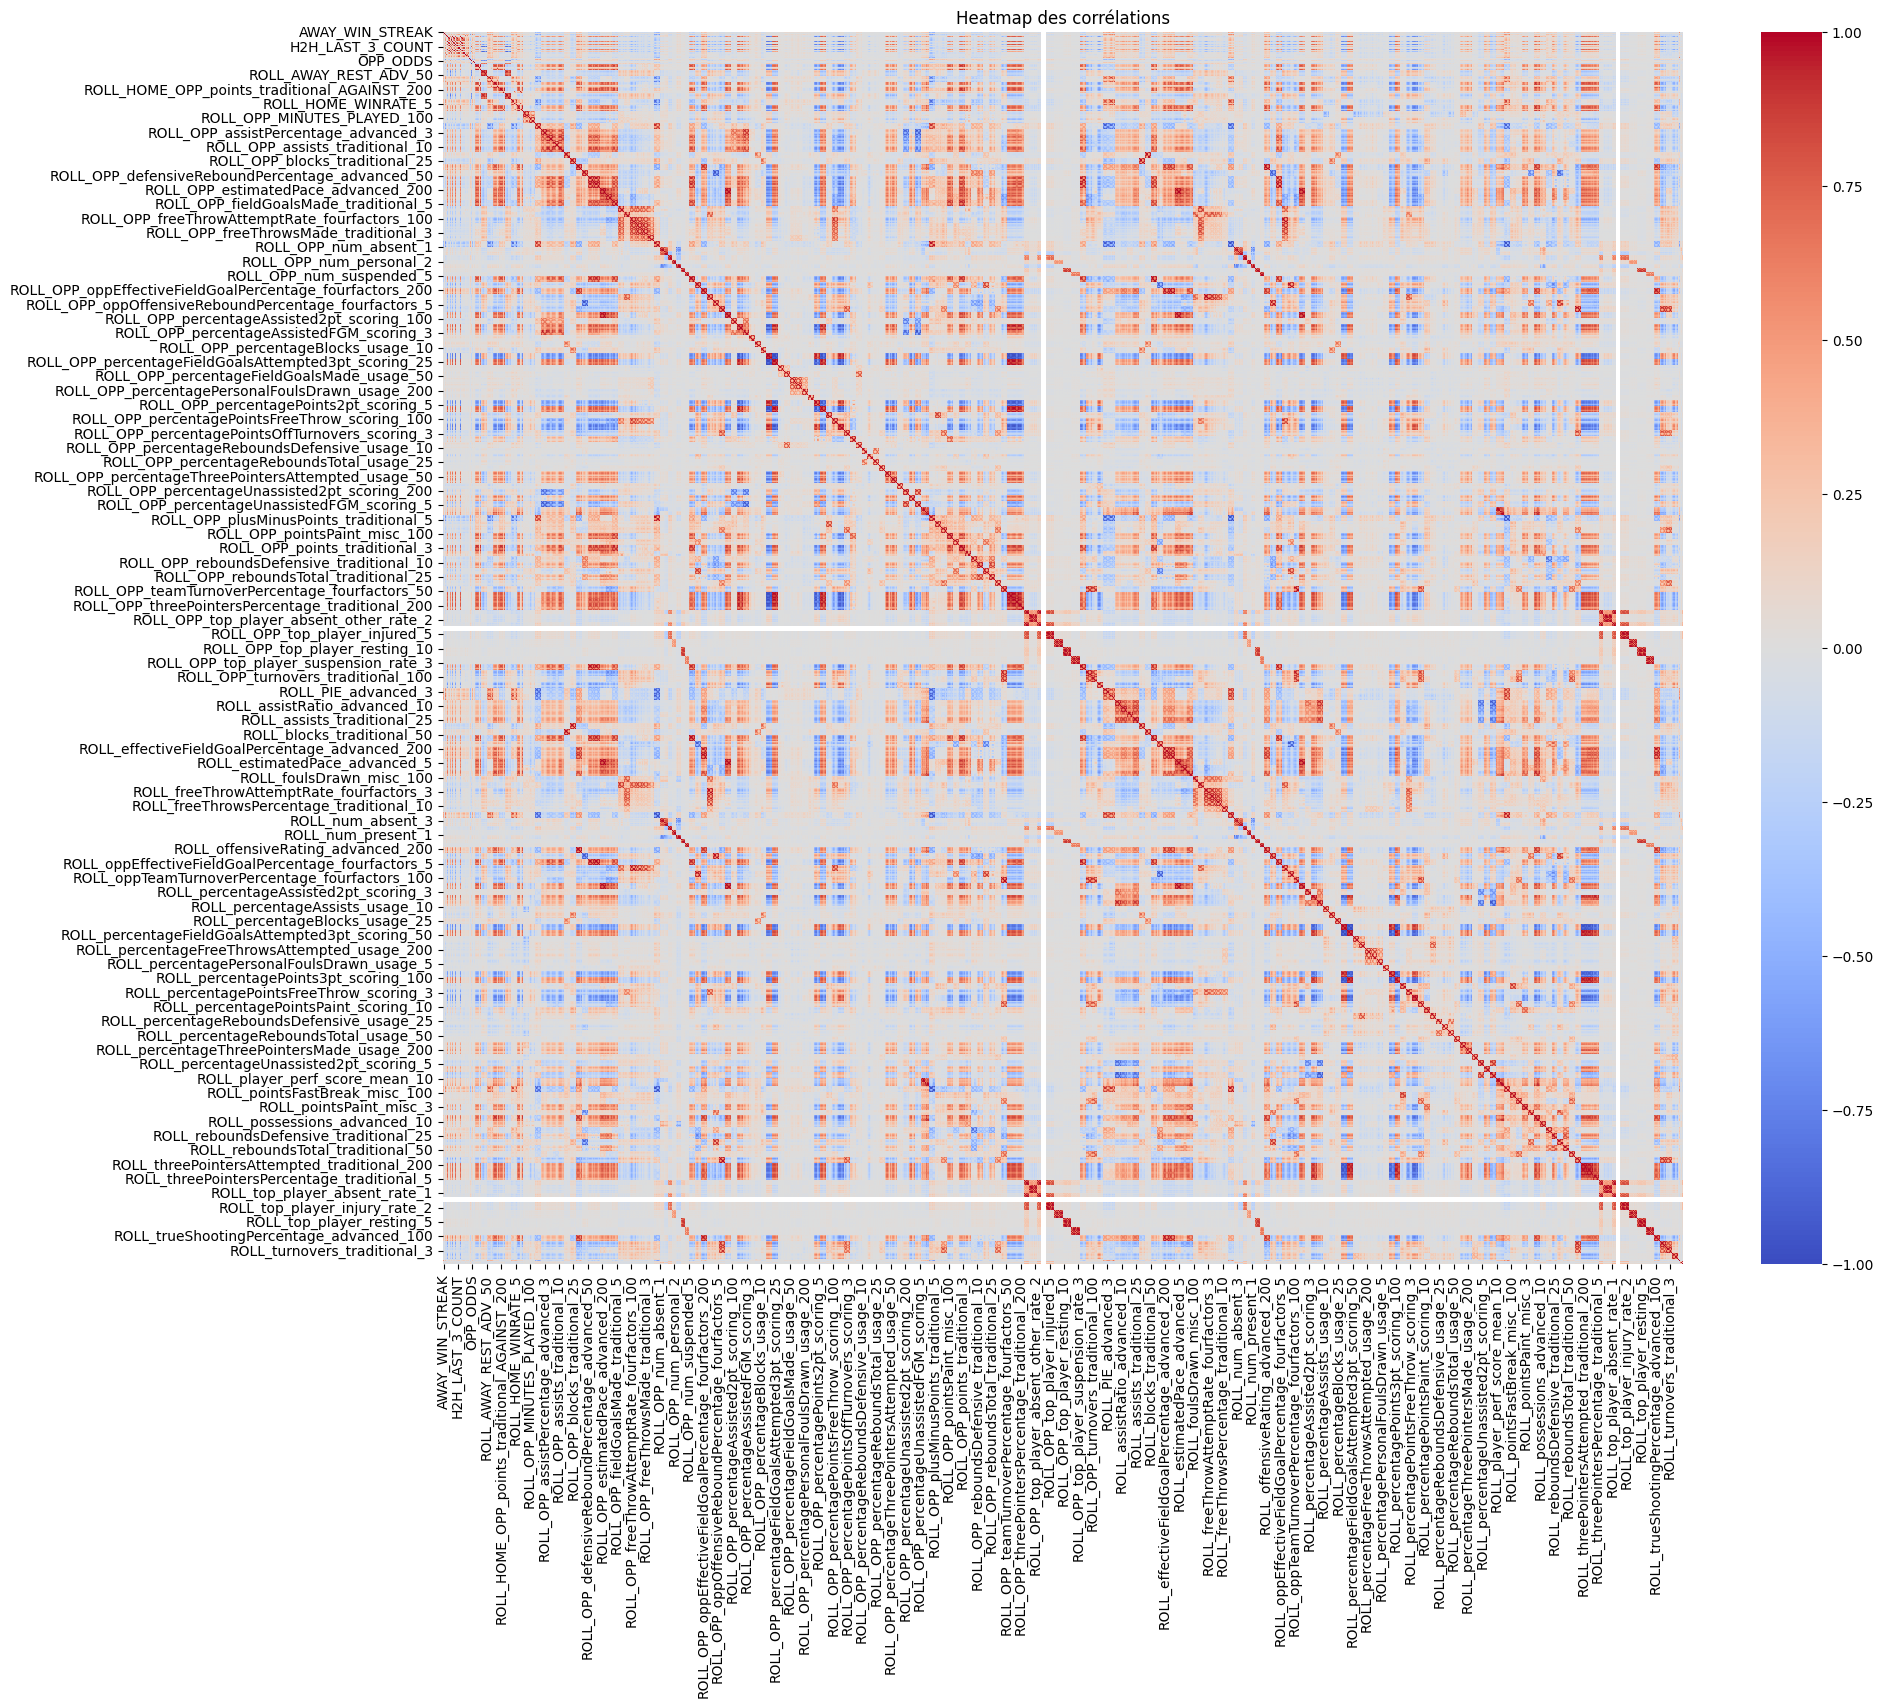

In [4]:
def quick_eda(df):
    display("Colonnes:", df.columns.tolist())
    display("Échantillon:\n", df.tail(4))
    display("Distribution des cibles:\n", df['IS_WIN'].value_counts(normalize=True))
    display("Valeurs manquantes:\n", df.isnull().sum().sort_values(ascending=False).head(10))

    num_cols = df.select_dtypes(include=[np.number]).columns.difference(['IS_WIN'])
    corr = df[num_cols].corr()
    plt.figure(figsize=(20, 16))
    sns.heatmap(corr, cmap='coolwarm', vmin=-1, vmax=1)
    plt.title("Heatmap des corrélations")
    plt.show()

quick_eda(df)


# -------- 2. Visualisation features clés --------


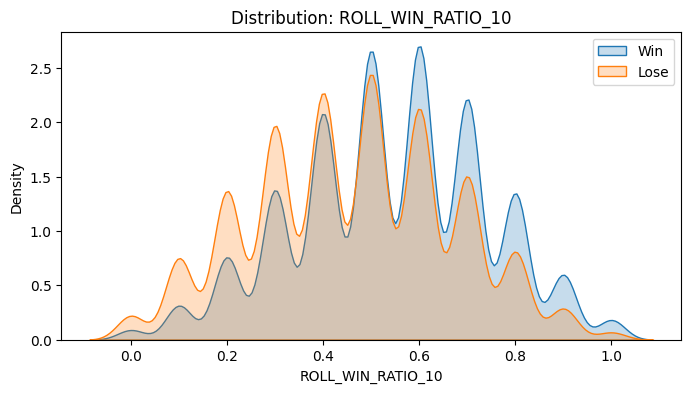

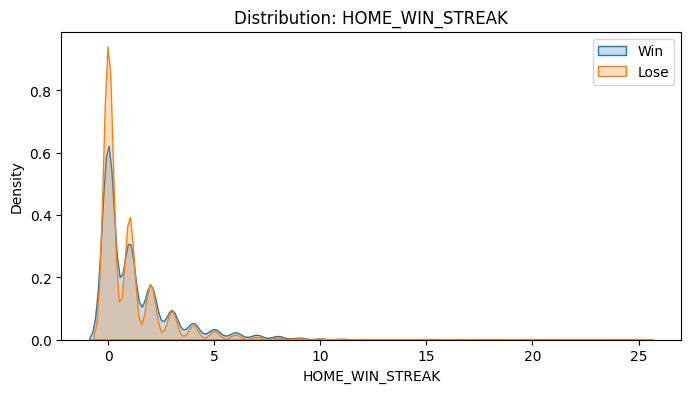

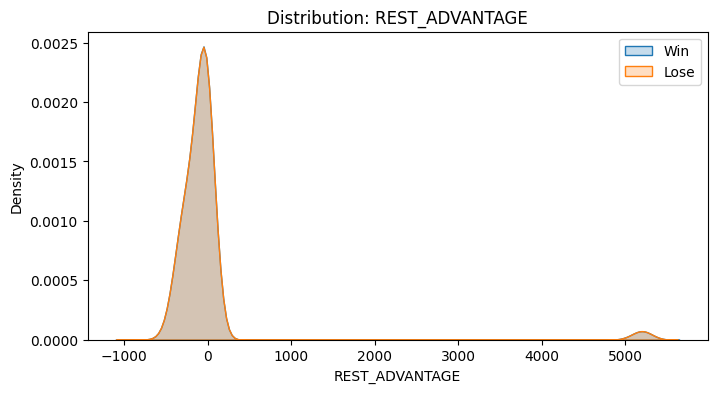

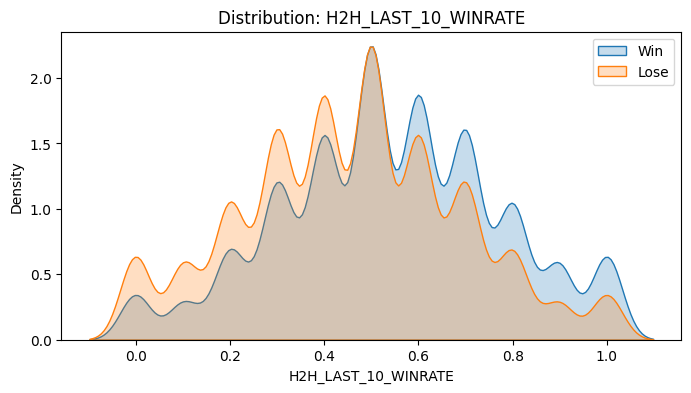

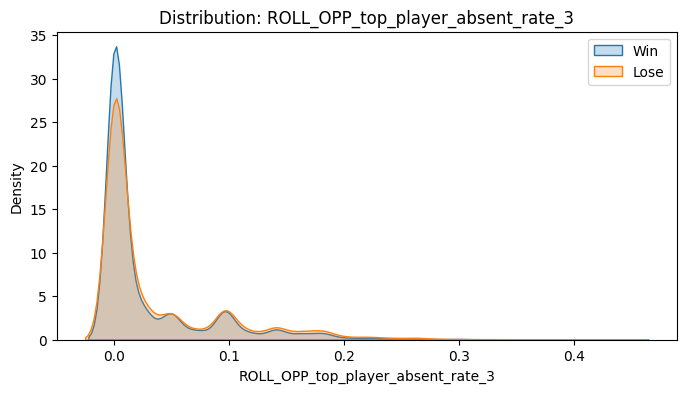

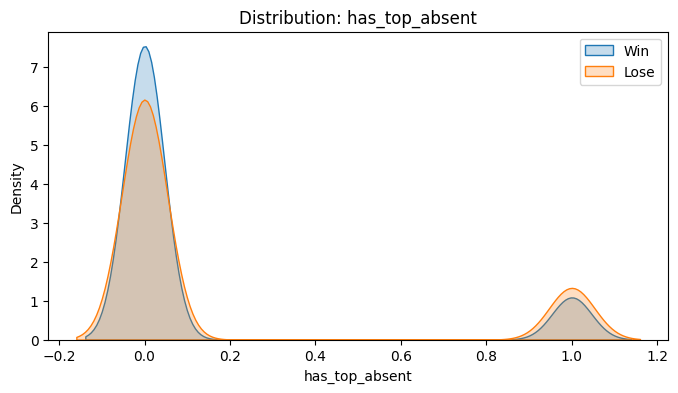

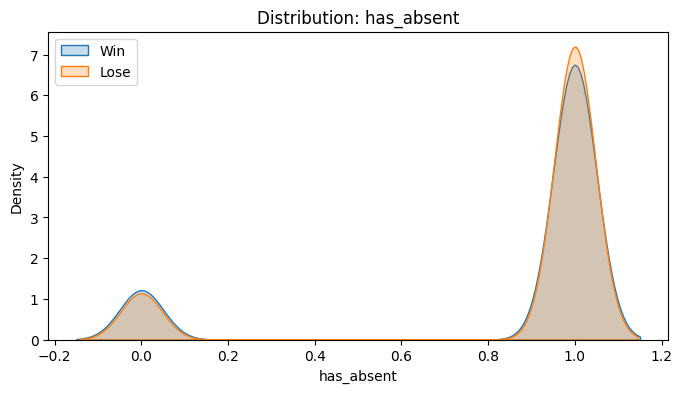

In [5]:

def plot_feature_distributions(df, features, target='IS_WIN'):
    for feat in features:
        if feat in df.columns:
            plt.figure(figsize=(8, 4))
            sns.kdeplot(df[df[target] == 1][feat].dropna(), label='Win', fill=True)
            sns.kdeplot(df[df[target] == 0][feat].dropna(), label='Lose', fill=True)
            plt.title(f'Distribution: {feat}')
            plt.legend()
            plt.show()

plot_feature_distributions(df, [
    'ROLL_WIN_RATIO_10', 'HOME_WIN_STREAK', 'REST_ADVANTAGE',
    'H2H_LAST_10_WINRATE', 'ROLL_OPP_top_player_absent_rate_3',
    'has_top_absent','has_absent'
])

# -------- 3. Préparation train/test --------


In [6]:

def prepare_train_test(df, target='IS_WIN', drop_cols=[]):
    features = df.columns.difference([target] + drop_cols)
    df = df.dropna(subset=features)
    X = df[features]
    y = df[target]
    split_index = int(len(df) * 0.8)
    return X.iloc[:split_index], X.iloc[split_index:], y.iloc[:split_index], y.iloc[split_index:]

drop_cols = COLS_TO_DROP_TARGET_IS_WIN #+ COLS_ODDS
X_train, X_test, y_train, y_test = prepare_train_test(df, drop_cols=drop_cols)


# -------- 4. Modélisation et Évaluation --------

In [7]:

def print_classification_metrics(y_true, y_pred, y_proba):
    print("Accuracy:", accuracy_score(y_true, y_pred))
    print("Precision:", precision_score(y_true, y_pred))
    print("Recall:", recall_score(y_true, y_pred))
    print("F1 Score:", f1_score(y_true, y_pred))
    print("ROC AUC:", roc_auc_score(y_true, y_proba))
    print("Log Loss:", log_loss(y_true, y_proba))
    print("Confusion Matrix:\n", confusion_matrix(y_true, y_pred))

def evaluate_model(model, X_train, y_train, X_test, y_test, name="Model"):
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    probas = model.predict_proba(X_test)[:, 1]
    
    print(f"========= {name} evaluation =========")
    
    #print(f"{name} - Classification report:\n", classification_report(y_test, preds))
    #print(f"{name} - ROC AUC: {roc_auc_score(y_test, probas):.4f}")
    
    print_classification_metrics(y_test, preds, probas)
    return model, probas


rf = RandomForestClassifier(n_estimators=100, random_state=42)
evaluate_model(rf, X_train, y_train, X_test, y_test, "Random Forest")

xgb = XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.05, subsample=0.7, colsample_bytree=0.7, use_label_encoder=False, eval_metric='logloss', random_state=42)
evaluate_model(xgb, X_train, y_train, X_test, y_test, "XGBoost")

cat = CatBoostClassifier(iterations=200, depth=6, learning_rate=0.05, random_seed=42, verbose=0)
evaluate_model(cat, X_train, y_train, X_test, y_test, "CatBoost")


========= Random Forest evaluation =========
Accuracy: 0.621419185282523
Precision: 0.6214719071485096
Recall: 0.6196738558653341
F1 Score: 0.6205715790860002
ROC AUC: 0.6660266848717393
Log Loss: 0.6584115164317036
Confusion Matrix:
 [[2373 1435]
 [1446 2356]]


e:\Documents_\Dev\NBA_Predictor\.venv\Lib\site-packages\xgboost\training.py:183: UserWarning: [21:30:09] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


========= XGBoost evaluation =========
Accuracy: 0.6670170827858082
Precision: 0.6725639629831247
Recall: 0.6499210941609679
F1 Score: 0.6610486891385767
ROC AUC: 0.733936438528594
Log Loss: 0.6024766737584617
Confusion Matrix:
 [[2605 1203]
 [1331 2471]]
========= CatBoost evaluation =========
Accuracy: 0.6806833114323259
Precision: 0.6773526370217167
Recall: 0.6891109942135718
F1 Score: 0.6831812255541069
ROC AUC: 0.7499850117585172
Log Loss: 0.5907626405580281
Confusion Matrix:
 [[2560 1248]
 [1182 2620]]


(<catboost.core.CatBoostClassifier at 0x22b46ebec50>,
 array([0.81702101, 0.15406434, 0.59682912, ..., 0.41209916, 0.41828323,
        0.61967262], shape=(7610,)))

# -------- 5. SHAP --------


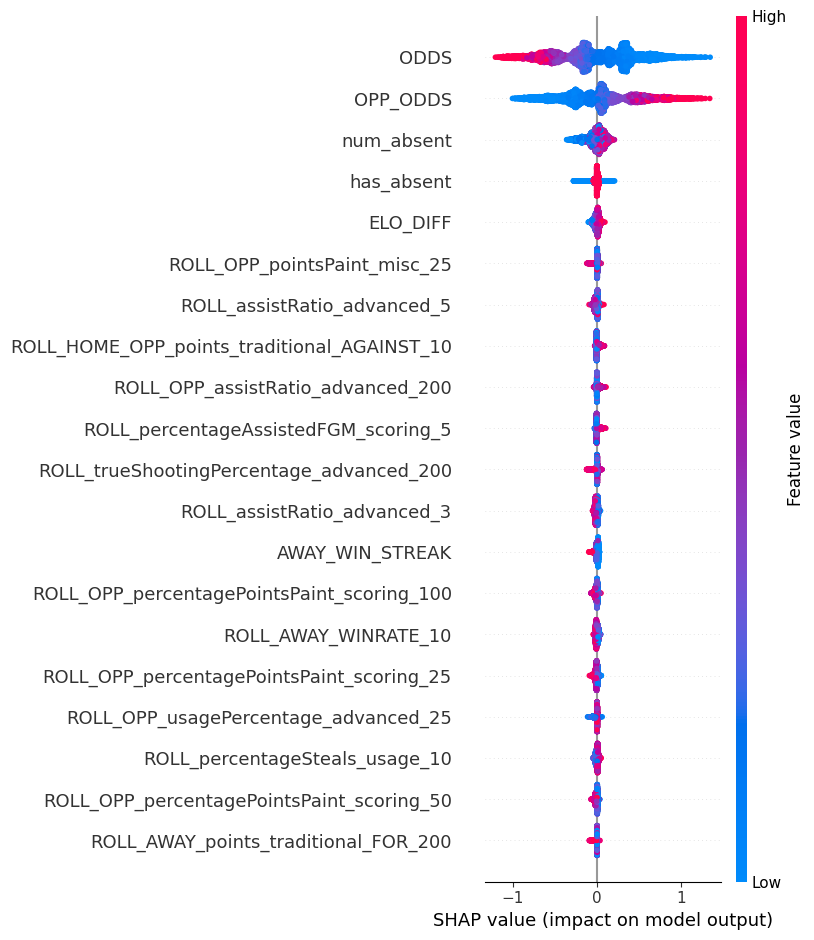

In [8]:
explainer = shap.Explainer(xgb)
shap_values = explainer(X_test)
shap.summary_plot(shap_values, X_test)


# -------- 6. TimeSeriesSplit CV --------


In [ ]:
tscv = TimeSeriesSplit(n_splits=5)
X_all = pd.concat([X_train, X_test])
y_all = pd.concat([y_train, y_test])
scores = cross_val_score(xgb, X_all, y_all, cv=tscv, scoring='roc_auc')
print("XGB TimeSeries CV ROC AUC:", scores.mean())

# same for CatBoost
scores_cat = cross_val_score(cat, X_all, y_all, cv=tscv, scoring='roc_auc') 
print("CatBoost TimeSeries CV ROC AUC:", scores_cat.mean())


e:\Documents_\Dev\NBA_Predictor\.venv\Lib\site-packages\xgboost\training.py:183: UserWarning: [21:32:15] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
e:\Documents_\Dev\NBA_Predictor\.venv\Lib\site-packages\xgboost\training.py:183: UserWarning: [21:33:03] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
e:\Documents_\Dev\NBA_Predictor\.venv\Lib\site-packages\xgboost\training.py:183: UserWarning: [21:34:32] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
e:\Documents_\Dev\NBA_Predictor\.venv\Lib\site-packages\xgboost\training.py:183: UserWarning: [21:36:21] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "

TimeSeries CV ROC AUC: 0.7327351141349702


# -------- 7. Learning Curves --------


In [ ]:
def plot_learning_curve(model, X, y, name="Model"):
    train_sizes, train_scores, test_scores = learning_curve(model, X, y, cv=3, scoring='roc_auc')
    plt.plot(train_sizes, test_scores.mean(axis=1))
    plt.title(f'{name} Learning Curve')
    plt.xlabel('Training examples')
    plt.ylabel('ROC AUC')
    plt.show()

plot_learning_curve(xgb, pd.concat([X_train, X_test]), pd.concat([y_train, y_test]), "XGBoost")
plot_learning_curve(cat, pd.concat([X_train, X_test]), pd.concat([y_train, y_test]), "CatBoost")

e:\Documents_\Dev\NBA_Predictor\.venv\Lib\site-packages\xgboost\training.py:183: UserWarning: [21:40:18] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
e:\Documents_\Dev\NBA_Predictor\.venv\Lib\site-packages\xgboost\training.py:183: UserWarning: [21:41:15] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
e:\Documents_\Dev\NBA_Predictor\.venv\Lib\site-packages\xgboost\training.py:183: UserWarning: [21:42:50] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
e:\Documents_\Dev\NBA_Predictor\.venv\Lib\site-packages\xgboost\training.py:183: UserWarning: [21:44:18] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "

In [ ]:
end_time = datetime.datetime.now()
print("End time: ", end_time)
print("Total execution time: ", end_time - start_time)